# Fit and predict

Let both the mean and spread depend on a covariate, fit the model, and compare
uncertainty about the mean with uncertainty about a new response. This notebook
is self-contained and uses pandas and plotnine; model graphs need Graphviz. For the building blocks, see {doc}`11-model-building`.

## Generate data

We use $\mu_i=\beta_0+\beta_1 x_i$ and
$\sigma_i=\exp(\gamma_0+\gamma_1 x_i)$ in
$y_i\sim\mathcal{N}(\mu_i,\sigma_i^2)$. A linear log-scale predictor keeps the
standard deviation positive.

In [1]:
import jax
import jax.numpy as jnp
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

x_data = jnp.linspace(-1.0, 1.0, 120)
true_mean = 1.0 + 2.0 * x_data
true_scale = jnp.exp(-0.4 + 0.7 * x_data)
y_data = true_mean + true_scale * jax.random.normal(jax.random.key(8), (120,))

data = pd.DataFrame({"x": x_data, "y": y_data})

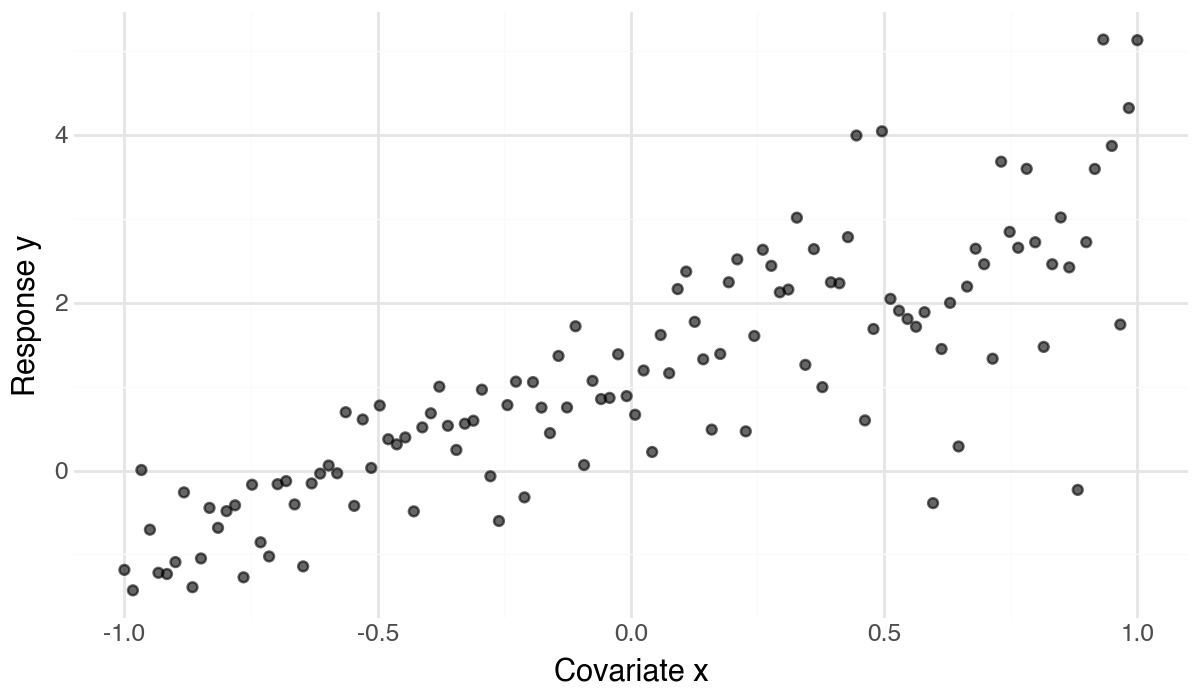

In [2]:
(
    p9.ggplot(data, p9.aes("x", "y"))
    + p9.geom_point(alpha=0.6, size=1.5)
    + p9.labs(x="Covariate x", y="Response y")
    + p9.theme_minimal()
    + p9.theme(figure_size=(6, 3.5))
).show()

The spread grows with `x`. A constant residual scale would hide this structure.
We can express the changing scale with the same calculator variables used for
the mean.

## Define predictors

In [3]:
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.5),
    name="beta",
)

gamma = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="gamma",
)

x = lsl.Var.new_obs(x_data, name="x")

# Mean predictor
mu = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu",
)

# Scale predictor
log_sigma = lsl.Var.new_calc(
    lambda x, g: g[0] + g[1] * x,
    x,
    gamma,
    name="log_sigma",
)
sigma = lsl.Var.new_calc(jnp.exp, log_sigma, name="sigma")

# Response
y = lsl.Var.new_obs(
    y_data,
    dist=lsl.Dist(tfd.Normal, loc=mu, scale=sigma),
    name="y",
)
model = lsl.Model(y)

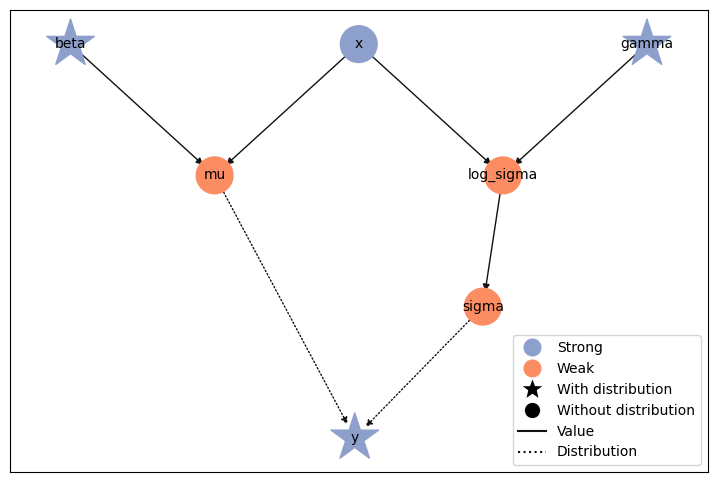

In [4]:
model.plot(width=9, height=6)

The graph has two paths into the response distribution. Both reuse `x`, but
each has its own coefficients and prior. We place normal priors directly on
the log-scale coefficients. This is a modeling choice, not a transformation
of some previously specified prior on `sigma`; see
{doc}`../../model-transformations` for that distinction.

## Fit with Goose

Put both coefficient vectors into one NUTS block. Small random perturbations
give the chains different starting positions. All parameters are unconstrained.

In [5]:
for parameter in model.parameters.values():
    parameter.inference = gs.MCMCSpec(
        gs.NUTSKernel,
        kernel_group="regression",
        jitter_dist=tfd.Normal(loc=0.0, scale=0.1),
    )

results = gs.LieselMCMC(model).run_for_epochs(
    seed=31,
    num_chains=4,
    adaptation=500,
    posterior=500,
    show_progress=False,
)
samples = results.get_posterior_samples()

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


The fit supplies draws for both `beta` and `gamma`. {meth}`Model.predict <liesel.model.Model.predict>` will
propagate those draws through the graph; the model's current parameter values
are not a substitute for them.

## Check the fit

In [6]:
summary = gs.Summary(
    results,
    which=["mean", "sd", "rhat", "ess_bulk", "ess_tail"],
)

In [7]:
summary.to_dataframe().round(3)

,var_fqn,kernel,var_index,sample_size,mean,sd,ess_bulk,ess_tail,rhat
variable,,,,,,,,,
beta,beta[0],kernel_00,"(0,)",2000,1.107,0.071,1535.689,1476.308,1.002
beta,beta[1],kernel_00,"(1,)",2000,2.137,0.111,1586.530,1398.596,1.006
gamma,gamma[0],kernel_00,"(0,)",2000,-0.361,0.068,1935.003,1370.393,1.000
gamma,gamma[1],kernel_00,"(1,)",2000,0.657,0.104,1667.677,1404.754,1.001


The four coefficient estimates are close to the generating values: 1 and 2 for
the mean, −0.4 and 0.7 for log scale. The displayed `rhat` values are close to 1
and effective sample sizes exceed 1,000 here. Check that agreement and precision
are sufficient for the quantities you want to estimate; these summaries alone
do not establish convergence.

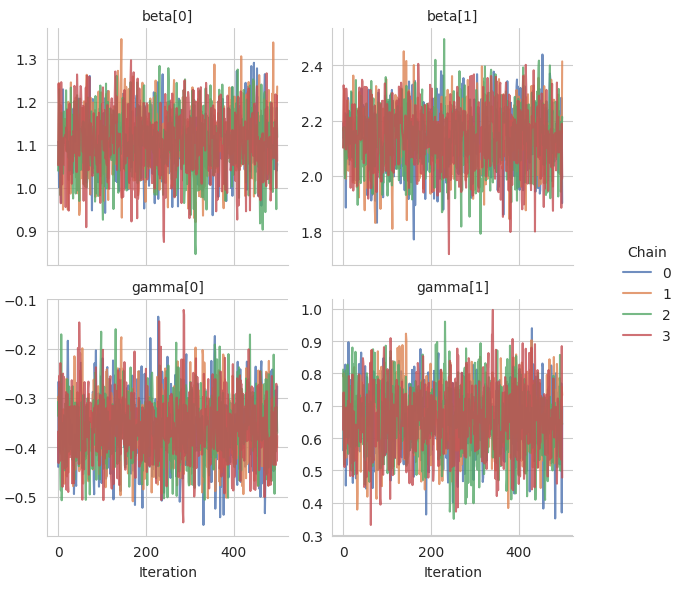

In [8]:
gs.plot_trace(results, ncol=2);

Look for overlapping chains without long drifts or stuck segments. If your fit
has poor agreement, persistent structure, or sampler errors, investigate it
before interpreting the following plots. See {class}`~liesel.goose.Summary`
and {doc}`../md/01c-transform` for further diagnostics and sampling examples.

## Predict on a grid

In [9]:
x_grid = jnp.linspace(-1.0, 1.0, 60)
predicted = model.predict(
    samples,
    predict=["mu", "sigma"],
    newdata={"x": x_grid},
)

In [10]:
{name: value.shape for name, value in predicted.items()}

{'mu': (4, 500, 60), 'sigma': (4, 500, 60)}

Each result has axes **chain × draw × grid point**, with shape `(4, 500, 60)`.
`mu` describes the mean and `sigma` the standard deviation for each draw.
Neither is a random new response. Selecting these outputs evaluates their
parental submodel, so no replacement response data are needed yet.

In [11]:
summary = gs.SamplesSummary(
    predicted,
    quantiles=(0.05, 0.5, 0.95),
    which=["quantiles"],
)
mean_q = summary.quantities["quantile"]["mu"]
scale_q = summary.quantities["quantile"]["sigma"]
scale_data = pd.DataFrame(
    {"x": x_grid, "lower": scale_q[0], "median": scale_q[1], "upper": scale_q[2]}
)
generating = pd.DataFrame({"x": x_data, "scale": true_scale})

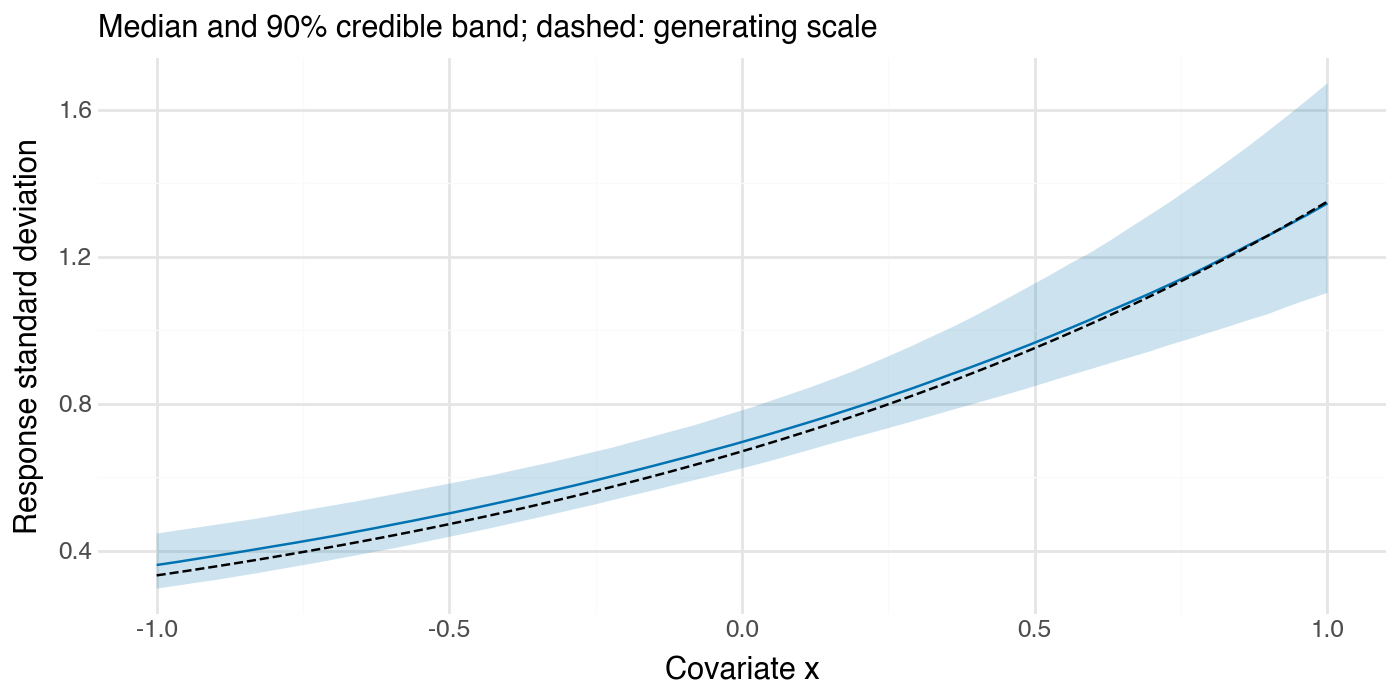

In [12]:
(
    p9.ggplot(scale_data, p9.aes("x", "median"))
    + p9.geom_ribbon(p9.aes(ymin="lower", ymax="upper"), fill="#0072B2", alpha=0.2)
    + p9.geom_line(color="#0072B2")
    + p9.geom_line(
        p9.aes("x", "scale"), data=generating, linetype="dashed", inherit_aes=False
    )
    + p9.labs(
        x="Covariate x",
        y="Response standard deviation",
        subtitle="Median and 90% credible band; dashed: generating scale",
    )
    + p9.theme_minimal()
    + p9.theme(figure_size=(7, 3.5))
).show()

The median follows the increasing generating scale; its dashed curve lies
inside the 90% band in this run. The band widens toward larger `x`, where
response variation is greater. It describes uncertainty about the scale,
not a range for future responses. The generating curve is available only
because we simulated these data.

In [13]:
replicated = model.sample(
    sample_shape=(),
    seed=jax.random.key(29),
    posterior_samples=samples,
    newdata={"x": x_grid, "y": jnp.zeros_like(x_grid)},
)

In [14]:
replicated["y"].shape

(4, 500, 60)

In [15]:
response_summary = gs.SamplesSummary(
    {"y": replicated["y"]},
    quantiles=(0.05, 0.5, 0.95),
    which=["quantiles"],
)
response_q = response_summary.quantities["quantile"]["y"]

`shape=()` requests one dataset per posterior draw. Both parameter vectors are
provided, so only response variation is added. The zero-valued response
placeholder sets the new length to 60; its values are replaced by simulation.
The result again has shape `(4, 500, 60)`. Use a fresh random key for another
replication; see {doc}`../../model-simulation` for prior and conditional draws.

## Compare intervals

In [16]:
intervals = pd.concat(
    [
        pd.DataFrame({"x": x_grid, "lower": q[0], "upper": q[2], "quantity": label})
        for q, label in [(mean_q, "Mean"), (response_q, "New response")]
    ]
)
mean_data = pd.DataFrame({"x": x_grid, "median": mean_q[1]})

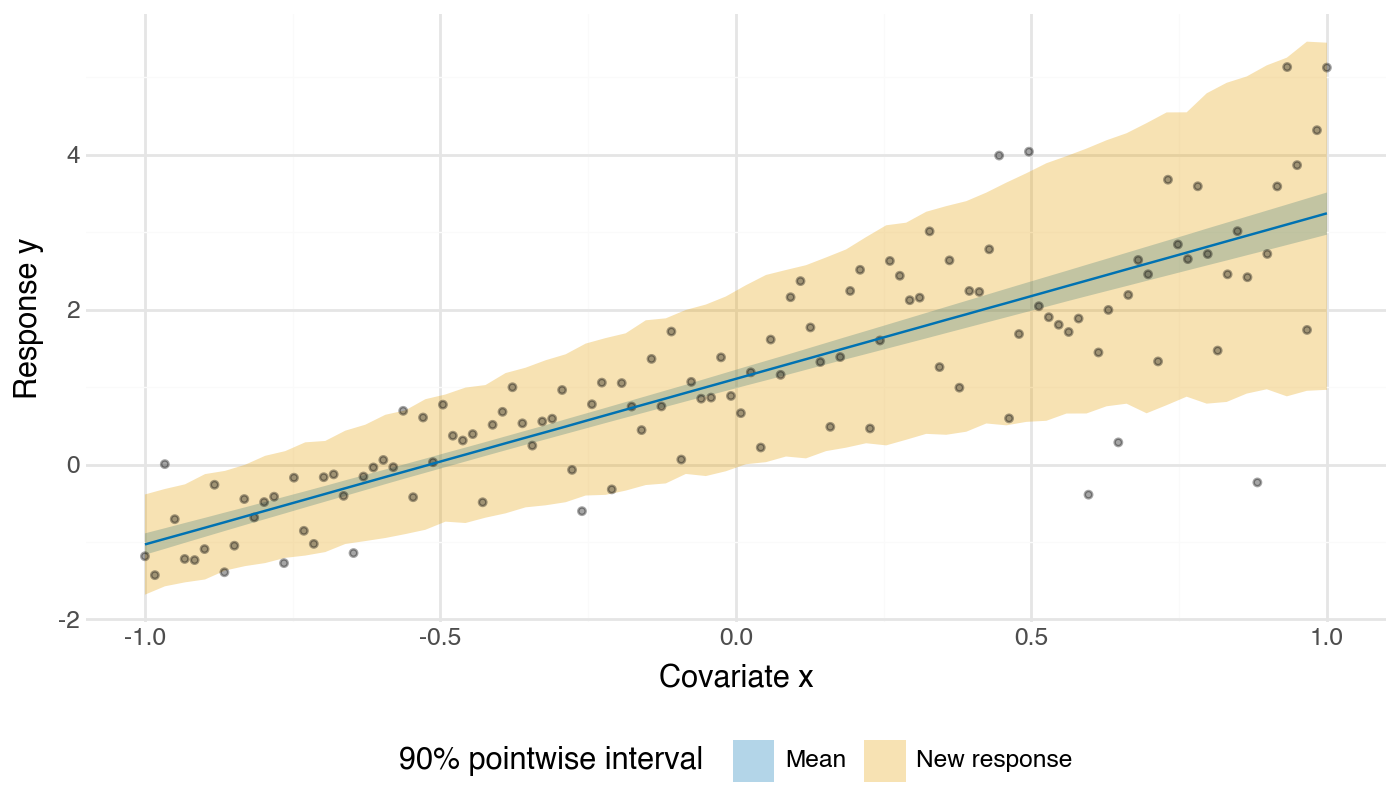

In [17]:
(
    p9.ggplot(intervals, p9.aes("x"))
    + p9.geom_ribbon(p9.aes(ymin="lower", ymax="upper", fill="quantity"), alpha=0.3)
    + p9.geom_point(p9.aes("x", "y"), data=data, alpha=0.35, size=1, inherit_aes=False)
    + p9.geom_line(p9.aes(y="median"), data=mean_data, color="#0072B2")
    + p9.scale_fill_manual(values={"Mean": "#0072B2", "New response": "#E69F00"})
    + p9.labs(x="Covariate x", y="Response y", fill="90% pointwise interval")
    + p9.theme_minimal()
    + p9.theme(figure_size=(7, 4), legend_position="bottom")
).show()

The mean band reflects parameter uncertainty. The wider predictive band also
includes random response variation and grows with the fitted standard deviation.
Both intervals are pointwise: each applies at one grid value, not to a whole
curve simultaneously. Overlap with the observed data is a useful visual check,
not a held-out assessment of predictive accuracy.

Use {doc}`../../model-prediction` for other named quantities and
{doc}`../../model-distributions` for pointwise log likelihoods.

(different-covariates)=
## Use different covariates

The two predictors need not use the same covariates. More generally, write
$\mu=X\beta$ and $\sigma=\exp(Z\gamma)$, where `X` and `Z` may have different
columns. Create a separate observed input for each design matrix and use it
in the corresponding calculator. Each coefficient vector must match its own
matrix's columns, and both matrices must describe the same observation rows.
Fit that model to its training designs before interpreting its posterior.

For prediction, pass both new designs, for example
`newdata={"X": X_new, "Z": Z_new}`, and select both `mu` and `sigma`. Align
rows in the two matrices: row `i` must refer to the same prediction case.
Keep each matrix's training column order, intercept convention, and encoding.

A curve against one covariate is a slice through this larger input space. If
`X_new` varies a mean covariate while `Z_new` holds the scale covariate fixed,
the predicted mean varies along the curve while the predicted scale stays
constant within each draw. State the fixed values in the plot description.
Do not reuse the draws above for a differently fitted model: changing the
training design changes the posterior.
